# 03 — Pre-Event State Conditioning

## Research question

Notebook 02 estimated the **unconditional** response of ES futures to macroeconomic surprises.
CPI is the only strong signal: a 1-SD hotter headline print lowers ES by roughly 18–24 bps.

This notebook asks:

> **Does the market's state *before* the release change how ES responds to the *same* surprise?**

If it does, a strategy can scale or filter trades by state (Notebook 04). If it does not, that is also a result: the surprise-only model is the right benchmark.

## Notebook Workflow

| Step | What happens | Output |
|---|---|---|
| 1 | Setup, paths, pre-registered parameters | — |
| 2 | Load NB02 event data, build the signed surprise `x` | event table |
| 3 | Load ES 1-minute data, roll-adjust the continuous contract | adjusted log price |
| 4 | Daily close and daily state features | `rv_20d`, `mom_20d`, `dd_60d`, … |
| 5 | Event-level state features and no-look-ahead checks | state table |
| 6 | Post-release drift returns (the tradeable part) | `drift_{h}m_bps` |
| 7 | State descriptives | correlations, bucket balance |
| 8 | Bucket analysis: surprise beta in Low / Mid / High states | `nb03_bucket_betas.csv` |
| 9 | Interaction regressions | `nb03_interaction_results.csv` |
| 10 | Permutation tests and multiple-testing (BH-FDR) correction | q-values |
| 11 | Subperiod stability (2016–2020 vs 2021–2026) | sign agreement |
| 12 | Does the state predict the **size** of the move? | `nb03_magnitude_results.csv` |
| 13 | Pre-registered selection rule, then hand-off to Notebook 04 | `nb03_state_selection.csv`, `event_state_features_2016_2026.parquet` |

## Methodology: design rules fixed *before* looking at results

1. **No look-ahead.** Every state variable for an event at time $T$ uses ES bars strictly before $T$. The last bar used is the $T-1$ bar, the same `pre_close` as in NB02. Daily features come from the 16:00 ET close of the previous trading day.
2. **Causal normalisation.** Each state is converted to a percentile against a **trailing 1-year** distribution ending before the event date. For intraday states the reference is measured at the **same clock time** (08:30 or 10:00 ET) every day. No full-sample z-scores or quantiles are used.
3. **Roll adjustment.** `ES.c.0` is an unadjusted continuous front-month series. Multi-day features use a roll-adjusted log price (1-minute returns across an `instrument_id` change are set to 0).
4. **Signed surprise.** One headline signal per family, signed by economic theory and NB02 so that $x>0$ means *good news for equities*:
   $x_{CPI} = -z_{headline\,CPI}$, $x_{PCE} = -z_{headline\,PCE}$, $x_{NFP} = +z_{payrolls}$. The sign is fixed, not re-estimated.
5. **Pre-registered states.** Six primary states, each with an economic hypothesis (table below). Everything else is labelled *exploratory*.
6. **Pre-registered targets.** `ret_5m_bps` (response including the instant jump) and `drift_30m_bps` (the post-release drift, which a strategy can actually trade).
7. **Multiple testing.** Benjamini–Hochberg FDR is applied across all interaction tests, together with a permutation test.

### Pre-registered state variables and hypotheses

| State | Definition (known before $T$) | Hypothesis |
|---|---|---|
| `rv_20d` | 20-day realised vol of daily closes (annualised %) | High-vol regimes → larger surprise beta (uncertainty, thinner liquidity) |
| `rv_pre_1d` | Realised vol of 5-min returns over the last ~23 trading hours (bps) | Short-term stress amplifies the reaction |
| `mom_20d` | 20-day log return (%) | After strong rallies, bad news hits harder (stretched positioning) |
| `dd_60d` | Distance from the 60-day high (%) | In drawdowns, the market is more sensitive to inflation news |
| `overnight_ret` | Prior 16:00 ET close → $T-1$ (bps) | A large pre-release move signals partial pre-positioning, so less left to react |
| `prev_x` | Previous signed surprise of the same family | Surprise streaks: a second hot print confirms the trend, so a larger response |

**Exploratory (reported, not used for selection):** `mom_5d`, `ma50_gap`, `rv_pre_60m`, `ret_pre_60m`.

## 1. Setup and Project Paths

In [1]:
from pathlib import Path
import sys
import importlib
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)
pd.set_option("display.max_rows", 120)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

# ------------------------------------------------------------
# Project paths (same convention as NB01/NB02)
# ------------------------------------------------------------
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = PROJECT_ROOT / "figures"
for d in [RESULTS_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

EVENT_MODEL_FILE = PROCESSED_DIR / "macro_event_model_data_2016_2026.parquet"
ES_RAW_FILE = RAW_DIR / "ES_1m_2010_2026_full.parquet"   # has instrument_id (needed for rolls)

# Helper module
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
import src.state_conditioning as sc
importlib.reload(sc)

print("Project root:", PROJECT_ROOT)
print("Event file exists:", EVENT_MODEL_FILE.exists())
print("ES raw file exists:", ES_RAW_FILE.exists())

Project root: /Users/reza/Desktop/mfe-term_3/BlackRock-Project-State-Dependent-Intraday-Response-of-S-P-500-Futures-to-Macroeconomic-Surprises
Event file exists: True
ES raw file exists: True


### 1.1 Pre-registered parameters
These are fixed **before** any result is examined. Changing them after seeing results would invalidate the multiple-testing correction.

In [2]:
FAMILIES = ["CPI", "NFP", "PCE", "ALL"]          # ALL = pooled, family-specific slopes

PRIMARY_STATES = ["rv_20d", "rv_pre_1d", "mom_20d", "dd_60d", "overnight_ret", "prev_x"]
EXPLORATORY_STATES = ["mom_5d", "ma50_gap", "rv_pre_60m", "ret_pre_60m"]

RET_TARGETS = [f"ret_{h}m_bps" for h in sc.HORIZONS]            # from T-1 (NB02 definition)
DRIFT_TARGETS = [f"drift_{h}m_bps" for h in sc.DRIFT_HORIZONS]  # from T (tradeable)
ALL_TARGETS = RET_TARGETS + DRIFT_TARGETS

PRIMARY_TARGETS = ["ret_5m_bps", "drift_30m_bps"]

TRAILING_WINDOW_DAYS = 365   # percentile reference window
SPLIT_DATE = "2021-01-01"    # subperiod split: 2016-2020 vs 2021-2026
N_PERM = 2000                # permutations per primary test
FDR_Q = 0.10

print("Primary states:", PRIMARY_STATES)
print("Primary targets:", PRIMARY_TARGETS)

Primary states: ['rv_20d', 'rv_pre_1d', 'mom_20d', 'dd_60d', 'overnight_ret', 'prev_x']
Primary targets: ['ret_5m_bps', 'drift_30m_bps']


## 2. Load NB02 Event Data and Build the Signed Surprise

In [4]:
events = pd.read_parquet(EVENT_MODEL_FILE)
events["timestamp_utc"] = pd.to_datetime(events["timestamp_utc"], utc=True)
events = events.sort_values("timestamp_utc").reset_index(drop=True)

print("Event rows:", len(events))
print("Unique timestamps:", events["timestamp_utc"].nunique())
print("Range:", events["timestamp_utc"].min(), "to", events["timestamp_utc"].max())
display(events["event_type"].value_counts().rename("n_events").to_frame())
display(events.head())

assert events["timestamp_utc"].is_unique
assert set(RET_TARGETS).issubset(events.columns)

Event rows: 363
Unique timestamps: 363
Range: 2016-01-08 13:30:00+00:00 to 2026-06-25 12:30:00+00:00


,n_events
event_type,
NFP,122
CPI,122
PCE,119


,timestamp_utc,event_type,avg_hourly_earnings,core_cpi,core_pce,headline_cpi,headline_pce,nonfarm_payrolls,unemployment_rate,pre_close,ret_1m_bps,ret_5m_bps,ret_15m_bps,ret_30m_bps,ret_60m_bps
0,2016-01-08 13:30:00+00:00,NFP,-0.9769,NaN,NaN,NaN,NaN,1.6143,0.4340,"1,950.5000",34.5468,65.1551,26.8800,17.9280,-19.2443
1,2016-01-20 13:30:00+00:00,CPI,NaN,-1.0924,NaN,-0.8034,NaN,NaN,NaN,"1,843.0000",-2.7133,6.7801,-1.3566,9.4909,9.4909
2,2016-02-01 13:30:00+00:00,PCE,NaN,NaN,-1.3234,NaN,-1.3212,NaN,NaN,"1,915.5000",1.3051,-2.6106,14.3463,11.7394,19.5580
3,2016-02-05 13:30:00+00:00,NFP,1.6753,NaN,NaN,NaN,NaN,-0.5663,-0.2453,"1,909.0000",-32.7934,-59.1057,-39.3650,-52.5211,-23.6004
4,2016-02-19 13:30:00+00:00,CPI,NaN,1.4020,NaN,1.1648,NaN,NaN,NaN,"1,910.5000",-14.4045,-3.9264,-7.8544,-27.5175,-23.5818


In [5]:
events = sc.add_signed_surprise(events)

print("Signed-surprise definition:")
for fam, (col, sign) in sc.FAMILY_SIGNAL.items():
    print(f"  {fam}: x = {sign:+.0f} * {col}")

print("\nMissing x by family:")
display(events.groupby("event_type")["x"].apply(lambda v: v.isna().sum()).rename("missing_x").to_frame())

# Sanity check: x should be POSITIVELY related to returns (by construction of the sign)
sanity = (
    events.groupby("event_type")
    .apply(lambda g: pd.Series({f"corr(x, {c})": g["x"].corr(g[c]) for c in ["ret_1m_bps", "ret_5m_bps", "ret_30m_bps"]}))
)
display(sanity)

Signed-surprise definition:
  CPI: x = -1 * headline_cpi
  PCE: x = -1 * headline_pce
  NFP: x = +1 * nonfarm_payrolls

Missing x by family:


,missing_x
event_type,
CPI,0
NFP,1
PCE,0


,"corr(x, ret_1m_bps)","corr(x, ret_5m_bps)","corr(x, ret_30m_bps)"
event_type,,,
CPI,0.5371,0.5149,0.4950
NFP,0.1327,0.1318,0.1879
PCE,0.3653,0.3061,0.1592


**Checkpoint.** For CPI (and PCE) the correlation between `x` and returns should be clearly **positive**, consistent with the negative headline coefficients in NB02. NFP will be weak, as in NB02.

## 3. Load ES 1-Minute Data and Roll-Adjust the Continuous Contract

In [6]:
es = sc.load_es_minute(ES_RAW_FILE)
print("ES bars:", len(es))
print("Range:", es.index.min(), "to", es.index.max())
print("Distinct instrument_ids:", es["instrument_id"].nunique())

es_adj, rolls = sc.build_adjusted_log_price(es)
print("\nNumber of contract rolls detected:", len(rolls))
display(rolls.tail(10))

ES bars: 4811336
Range: 2010-07-01 00:00:00+00:00 to 2026-06-30 23:59:00+00:00
Distinct instrument_ids: 65

Number of contract rolls detected: 64


,timestamp_utc,from_instrument,to_instrument,raw_jump_bps
54,2024-03-17 22:00:00+00:00,17077,5602,130.5875
55,2024-06-23 22:00:00+00:00,5602,118,133.6201
56,2024-09-22 22:00:00+00:00,118,183748,101.6300
57,2024-12-22 23:00:00+00:00,183748,5002,299.7885
58,2025-03-23 22:00:00+00:00,5002,4916,230.1886
59,2025-06-22 22:00:00+00:00,4916,14160,-55.0667
60,2025-09-21 22:00:00+00:00,14160,294973,93.8167
61,2025-12-21 23:00:00+00:00,294973,42140878,156.8974
62,2026-03-22 22:00:00+00:00,42140878,42140864,-109.0324
63,2026-06-19 00:00:00+00:00,42140864,42140870,64.6758


In [7]:
# Validation: the roll adjustment only removes jumps at instrument changes.
# Within a contract, adjusted log returns must equal raw log returns.
raw_r = np.log(es["close"]).diff().to_numpy()
same_contract = np.r_[False, es["instrument_id"].to_numpy()[1:] == es["instrument_id"].to_numpy()[:-1]]
max_diff = np.nanmax(np.abs(raw_r[same_contract] - es_adj["r1"].to_numpy()[same_contract]))
print("Max |raw - adjusted| 1-min return within contracts:", max_diff)
assert max_diff < 1e-12

print("\nRaw price jump at rolls (bps), which is removed from multi-day features:")
display(rolls["raw_jump_bps"].describe().to_frame())

Max |raw - adjusted| 1-min return within contracts: 0.0

Raw price jump at rolls (bps), which is removed from multi-day features:


,raw_jump_bps
count,64.0000
mean,-42.2225
std,177.7292
min,"-1,096.8706"
25%,-103.7564
50%,-40.1071
75%,39.9748
max,299.7885


**Why this matters.** The continuous series `ES.c.0` jumps at each quarterly roll by the calendar spread. Without adjustment, a 20-day momentum or drawdown measure spanning a roll would partly measure the spread, not the market move.

## 4. Daily Close and Daily State Features

In [8]:
daily = sc.build_daily_close(es_adj)
daily_feats = sc.compute_daily_features(daily)

print("Trading days:", len(daily))
print("Range:", daily.index.min().date(), "to", daily.index.max().date())
display(daily_feats.dropna().tail())
display(daily_feats[sc.DAILY_STATE].describe().T)

Trading days: 3395
Range: 2010-07-06 to 2026-06-30


,rv_20d,mom_5d,mom_20d,dd_60d,ma50_gap,daily_close_ts_utc
date_et,,,,,,
2026-06-24,16.9989,-2.4644,-1.4846,-3.2413,0.3140,2026-06-24 19:59:00+00:00
2026-06-25,16.7899,-1.8610,-2.1266,-3.2379,0.1888,2026-06-25 19:59:00+00:00
2026-06-26,16.8930,-1.2277,-2.7882,-3.8896,-0.5539,2026-06-26 19:59:00+00:00
2026-06-29,17.8051,-0.5752,-1.7742,-2.3200,0.9084,2026-06-29 19:59:00+00:00
2026-06-30,17.9702,1.4687,-1.3106,-1.6851,1.4282,2026-06-30 19:59:00+00:00


,count,mean,std,min,25%,50%,75%,max
rv_20d,"3,377.0000",15.3554,11.0399,3.1100,9.3799,12.7950,18.1331,100.4431
mom_5d,"3,390.0000",0.3249,2.4027,-20.1636,-0.6594,0.4733,1.5204,19.0481
mom_20d,"3,375.0000",1.2830,4.5147,-34.7690,-0.7536,1.6528,3.6996,28.3907
dd_60d,"3,346.0000",-2.7734,4.0558,-34.9686,-3.6521,-1.1022,-0.1536,0.0000
ma50_gap,"3,351.0000",1.4976,3.7031,-28.3698,-0.1608,1.9742,3.7093,13.0483


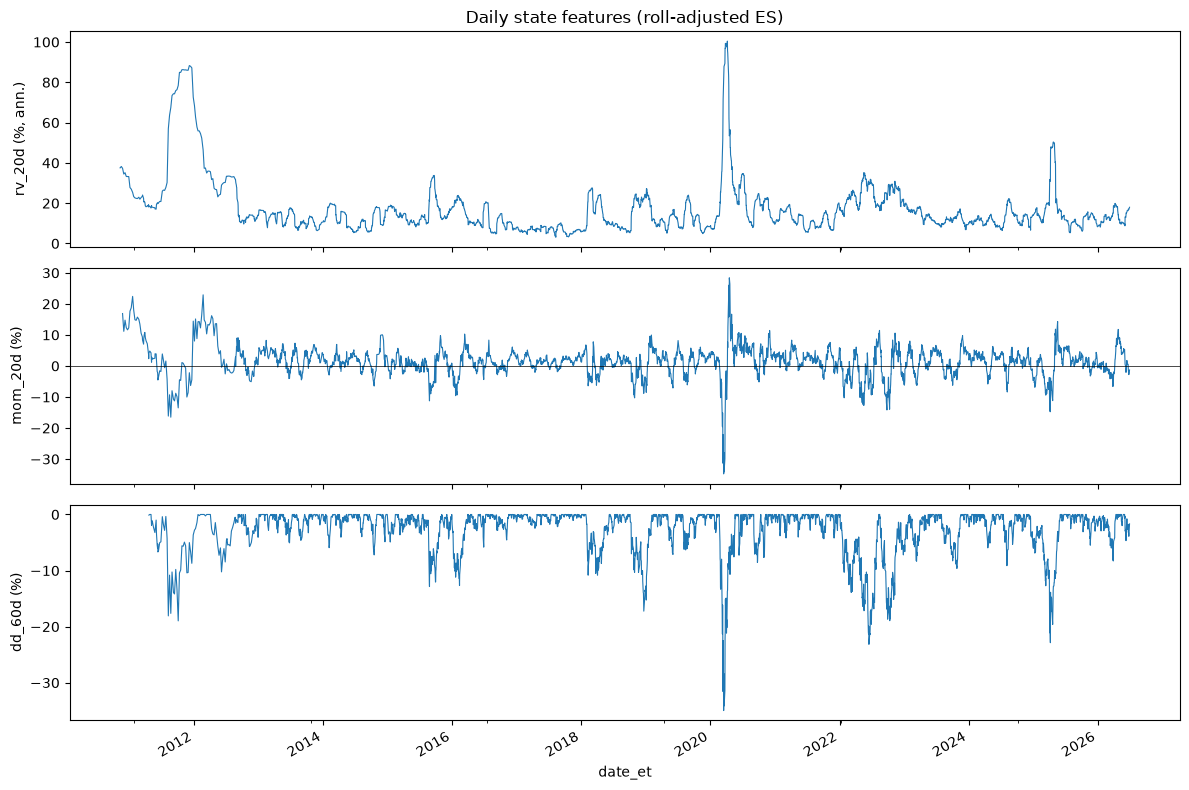

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
daily_feats["rv_20d"].plot(ax=axes[0], lw=0.8); axes[0].set_ylabel("rv_20d (%, ann.)")
daily_feats["mom_20d"].plot(ax=axes[1], lw=0.8); axes[1].axhline(0, c="k", lw=0.5); axes[1].set_ylabel("mom_20d (%)")
daily_feats["dd_60d"].plot(ax=axes[2], lw=0.8); axes[2].set_ylabel("dd_60d (%)")
axes[0].set_title("Daily state features (roll-adjusted ES)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "nb03_daily_state_features.png", dpi=150)
plt.show()

## 5. Event-Level State Features

For each event: daily features from the previous trading day; intraday features from bars before $T$; causal percentiles (`*_pct`); and the previous same-family surprise.

This step also computes the **same-clock-time reference distribution** for intraday states, which takes a little longer (roughly a minute).

In [10]:
ev = sc.build_event_states(events, es_adj, daily, daily_feats, window_days=TRAILING_WINDOW_DAYS)

ALL_STATES = PRIMARY_STATES + EXPLORATORY_STATES
ev = sc.add_state_buckets(ev, ALL_STATES)

show_cols = ["timestamp_utc", "event_type", "x"] + [c for s in PRIMARY_STATES for c in (s, f"{s}_pct")]
display(ev[show_cols].head(10))

,timestamp_utc,event_type,x,rv_20d,rv_20d_pct,rv_pre_1d,rv_pre_1d_pct,mom_20d,mom_20d_pct,dd_60d,dd_60d_pct,overnight_ret,overnight_ret_pct,prev_x,prev_x_pct
0,2016-01-08 13:30:00+00:00,NFP,1.6143,18.1901,0.7831,178.8675,0.9498,-5.9832,0.0571,-6.7933,0.1164,81.0763,0.9224,NaN,NaN
1,2016-01-20 13:30:00+00:00,CPI,0.8034,20.9393,0.8575,190.7138,0.9548,-6.9439,0.0339,-9.9436,0.0385,-170.8064,0.0271,NaN,NaN
2,2016-02-01 13:30:00+00:00,PCE,1.3212,23.5723,0.8946,109.2356,0.7175,-6.2352,0.0919,-6.9743,0.1726,-81.8878,0.0807,NaN,NaN
3,2016-02-05 13:30:00+00:00,NFP,-0.5663,23.5739,0.8872,162.0757,0.8938,-3.7639,0.1748,-8.0939,0.1394,-3.9280,0.4469,1.6143,0.9468
4,2016-02-19 13:30:00+00:00,CPI,-1.1648,21.7218,0.8231,102.9530,0.6507,3.3325,0.8624,-7.8454,0.1856,-20.9150,0.3231,0.8034,0.7891
5,2016-02-26 15:00:00+00:00,PCE,-2.1147,20.2670,0.7500,97.0139,0.5913,3.8831,0.9152,-6.0338,0.2848,30.7299,0.7217,1.3212,0.9068
6,2016-03-04 13:30:00+00:00,NFP,0.8511,19.2399,0.7208,64.4259,0.2554,4.3750,0.9416,-3.9023,0.3442,13.7992,0.5887,-0.5663,0.2856
7,2016-03-16 12:30:00+00:00,CPI,-0.1691,15.1494,0.5515,59.1112,0.1502,6.3365,0.9464,-2.7044,0.4313,-3.7219,0.4464,-1.1648,0.1221
8,2016-03-28 12:30:00+00:00,PCE,-0.3590,12.9674,0.3788,55.5440,0.1212,5.6374,0.9156,-1.6092,0.5823,28.3304,0.6970,-2.1147,0.0172
9,2016-04-01 12:30:00+00:00,NFP,0.2326,9.2469,0.0322,65.2424,0.2704,4.2892,0.8648,-0.2556,0.9034,-35.4112,0.2146,0.8511,0.8027


### 5.1 No-look-ahead validation

In [11]:
checks = {}

# (a) last intraday bar used is strictly before the release, and equals the NB02 pre-event bar (T-1)
checks["asof < T (all events)"] = bool((ev["asof_utc"] < ev["timestamp_utc"]).all())
checks["asof == T-1min (share)"] = float((ev["asof_utc"] == ev["timestamp_utc"] - pd.Timedelta(minutes=1)).mean())

# (b) raw close at the as-of bar matches NB02 pre_close
raw_pre = es["close"].reindex(ev["asof_utc"]).to_numpy()
checks["close(asof) == NB02 pre_close"] = bool(np.allclose(raw_pre, ev["pre_close"], equal_nan=False))

# (c) daily features come from a date strictly before the event date
checks["feature date < event date"] = bool((pd.to_datetime(ev["feat_date_et"]) < ev["date_et"]).all())

# (d) previous close used for overnight return is before T
checks["prev close ts < T"] = bool((pd.to_datetime(ev["prev_close_ts_utc"], utc=True) < ev["timestamp_utc"]).all())

# (e) prev_x only uses earlier events of the same family
first_idx = ev.groupby("event_type")["timestamp_utc"].idxmin()
checks["first event per family has no prev_x"] = bool(ev.loc[first_idx, "prev_x"].isna().all())

display(pd.Series(checks, name="result").to_frame())
assert checks["asof < T (all events)"]
assert checks["asof == T-1min (share)"] == 1.0
assert checks["close(asof) == NB02 pre_close"]
assert checks["feature date < event date"]
assert checks["prev close ts < T"]
print("ALL NO-LOOK-AHEAD CHECKS PASSED")

,result
asof < T (all events),True
asof == T-1min (share),1.0000
close(asof) == NB02 pre_close,True
feature date < event date,True
prev close ts < T,True
first event per family has no prev_x,True


ALL NO-LOOK-AHEAD CHECKS PASSED


### 5.2 State coverage

In [12]:
coverage = pd.DataFrame({
    "raw_non_missing": [ev[s].notna().sum() for s in ALL_STATES],
    "pct_non_missing": [ev[f"{s}_pct"].notna().sum() for s in ALL_STATES],
}, index=ALL_STATES)
coverage["n_events"] = len(ev)
coverage["primary"] = coverage.index.isin(PRIMARY_STATES)
display(coverage)

,raw_non_missing,pct_non_missing,n_events,primary
rv_20d,363,363,363,True
rv_pre_1d,363,363,363,True
mom_20d,363,363,363,True
dd_60d,363,363,363,True
overnight_ret,363,363,363,True
prev_x,359,359,363,True
mom_5d,363,363,363,False
ma50_gap,363,363,363,False
rv_pre_60m,363,363,363,False
ret_pre_60m,363,363,363,False


A few events may lack a percentile. This happens when the trailing reference window has fewer than 150 observations, or for the first event of each family (`prev_x`). Those events drop out of the tests for that state only.

## 6. Post-Release Drift Returns (the Tradeable Part)

NB02 returns run from the $T-1$ close and therefore include the **instant jump**, which no strategy reacting to the number can capture. The drift return starts at the close of the first post-release bar (label $T$):

$$D_{T,h} = \ln\left(\frac{P_{T+h-1}}{P_{T}}\right)$$

Because log returns add up: $R_{T,h} = R_{T,1} + D_{T,h}$. This identity is checked below.

In [13]:
ev = sc.add_drift_returns(ev, es_adj)

for h in sc.DRIFT_HORIZONS:
    gap = (ev[f"ret_{h}m_bps"] - (ev["ret_1m_bps"] + ev[f"drift_{h}m_bps"])).abs().max()
    print(f"h={h:>2}: max |ret_h - (ret_1 + drift_h)| = {gap:.2e} bps")
    assert gap < 1e-6

display(ev.groupby("event_type")[DRIFT_TARGETS].agg(lambda v: v.abs().mean()).round(2)
        .rename(columns=lambda c: "mean|" + c + "|"))

h= 5: max |ret_h - (ret_1 + drift_h)| = 3.28e-11 bps
h=15: max |ret_h - (ret_1 + drift_h)| = 3.46e-11 bps
h=30: max |ret_h - (ret_1 + drift_h)| = 3.16e-11 bps
h=60: max |ret_h - (ret_1 + drift_h)| = 3.34e-11 bps


,mean|drift_5m_bps|,mean|drift_15m_bps|,mean|drift_30m_bps|,mean|drift_60m_bps|
event_type,,,,
CPI,12.4800,16.3300,20.3800,20.4400
NFP,10.3000,14.7600,19.1000,21.7700
PCE,5.6200,10.4600,12.5500,15.1200


## 7. State Descriptives

,rv_20d_pct,rv_pre_1d_pct,mom_20d_pct,dd_60d_pct,overnight_ret_pct,prev_x_pct
rv_20d_pct,1.0000,0.5900,-0.3200,-0.6200,-0.0400,-0.0800
rv_pre_1d_pct,0.5900,1.0000,-0.4900,-0.7800,-0.0500,0.0000
mom_20d_pct,-0.3200,-0.4900,1.0000,0.6500,0.0300,-0.0300
dd_60d_pct,-0.6200,-0.7800,0.6500,1.0000,-0.0000,0.0700
overnight_ret_pct,-0.0400,-0.0500,0.0300,-0.0000,1.0000,-0.1300
prev_x_pct,-0.0800,0.0000,-0.0300,0.0700,-0.1300,1.0000


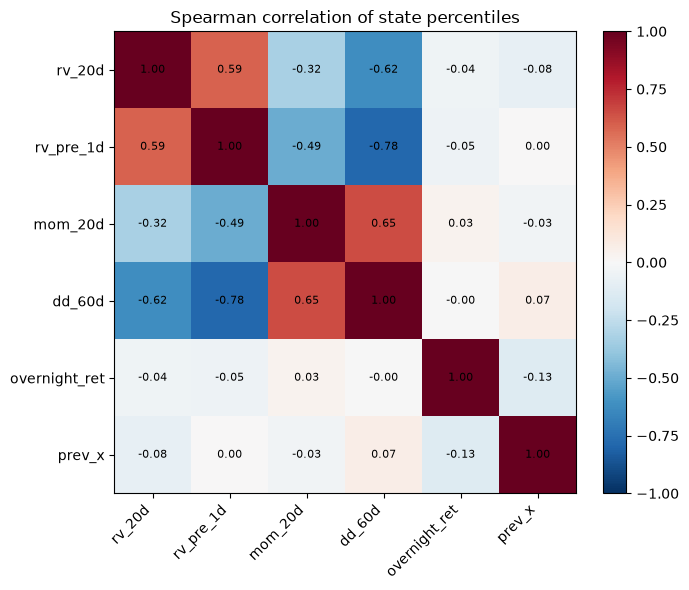

In [14]:
pct_cols = [f"{s}_pct" for s in PRIMARY_STATES]
corr = ev[pct_cols].corr(method="spearman")
display(corr.round(2))

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(pct_cols))); ax.set_xticklabels(PRIMARY_STATES, rotation=45, ha="right")
ax.set_yticks(range(len(pct_cols))); ax.set_yticklabels(PRIMARY_STATES)
for i in range(len(pct_cols)):
    for j in range(len(pct_cols)):
        ax.text(j, i, f"{corr.values[i, j]:.2f}", ha="center", va="center", fontsize=8)
plt.colorbar(im, ax=ax, fraction=0.046)
ax.set_title("Spearman correlation of state percentiles")
plt.tight_layout(); plt.savefig(FIGURES_DIR / "nb03_state_correlation.png", dpi=150); plt.show()

**How to read it.** Highly correlated states (for example `rv_20d` and `dd_60d`, since drawdowns coincide with high volatility) are **not independent evidence**. If both pass, treat them as one volatility/stress regime.

In [15]:
# Bucket balance: causal terciles need not be exactly 1/3 each, since they are relative to the trailing year
bal = pd.concat({s: ev[f"{s}_bucket"].value_counts(normalize=True) for s in PRIMARY_STATES}, axis=1).T
display(bal.round(2))

# Bucket counts per family, which shows how thin the cells are
display(pd.concat({s: ev.groupby("event_type")[f"{s}_bucket"].value_counts().unstack() for s in PRIMARY_STATES}))

,Low,High,Mid
rv_20d,0.4100,0.3200,0.2700
rv_pre_1d,0.3800,0.3300,0.2900
mom_20d,0.3600,0.3400,0.3100
dd_60d,0.3400,0.3600,0.3100
overnight_ret,0.3100,0.3300,0.3500
prev_x,0.2200,0.2400,0.5500


Low  Mid  High
              event_type                
rv_20d        CPI          53   30    39
              NFP          50   34    38
              PCE          47   34    38
rv_pre_1d     CPI          54   33    35
              NFP          42   39    41
              PCE          41   33    45
mom_20d       CPI          42   40    40
              NFP          47   37    38
              PCE          41   34    44
dd_60d        CPI          40   38    44
              NFP          45   36    41
              PCE          38   37    44
overnight_ret CPI          33   51    38
              NFP          37   50    35
              PCE          44   27    48
prev_x        CPI          38   47    36
              NFP          19   78    23
              PCE          21   71    26

## 8. Bucket Analysis: Surprise Beta by State Tercile

Within each state bucket $k\in\{\text{Low},\text{Mid},\text{High}\}$:

$$r_i = a_k + \beta_k\, x_i + \varepsilon_i$$

If the state matters, $\beta$ should change **monotonically** from Low to High. Standard errors are HC3.

In [16]:
bucket = sc.bucket_betas(ev, ALL_STATES, FAMILIES, ALL_TARGETS)
bucket.to_csv(RESULTS_DIR / "nb03_bucket_betas.csv", index=False)

cpi_view = (
    bucket[(bucket["family"] == "CPI") & bucket["state"].isin(PRIMARY_STATES) & bucket["target"].isin(PRIMARY_TARGETS)]
    .pivot_table(index=["state", "target"], columns="bucket", values="beta")
    [["Low", "Mid", "High"]]
)
cpi_view["High - Low"] = cpi_view["High"] - cpi_view["Low"]
print("CPI: surprise beta (bps per 1-SD good-news surprise) by state bucket")
display(cpi_view.round(2))

CPI: surprise beta (bps per 1-SD good-news surprise) by state bucket


bucket                          Low     Mid    High  High - Low
state         target                                           
dd_60d        drift_30m_bps  5.6200  7.0800  4.1800     -1.4400
              ret_5m_bps    35.8300 23.7100 12.5900    -23.2400
mom_20d       drift_30m_bps  1.8300  8.4800  8.4000      6.5700
              ret_5m_bps    29.3400 17.1200 29.3500      0.0100
overnight_ret drift_30m_bps -3.6200 11.0500 11.7000     15.3200
              ret_5m_bps     9.1300 27.9300 49.4800     40.3600
prev_x        drift_30m_bps  4.8000  6.9000 10.5700      5.7700
              ret_5m_bps    28.0800 27.2800 25.8500     -2.2300
rv_20d        drift_30m_bps  0.3000 18.9700 15.9400     15.6300
              ret_5m_bps    10.6100 67.5800 50.1900     39.5800
rv_pre_1d     drift_30m_bps  7.6000  6.5300  3.0900     -4.5100
              ret_5m_bps    24.5700 21.4300 29.4100      4.8400

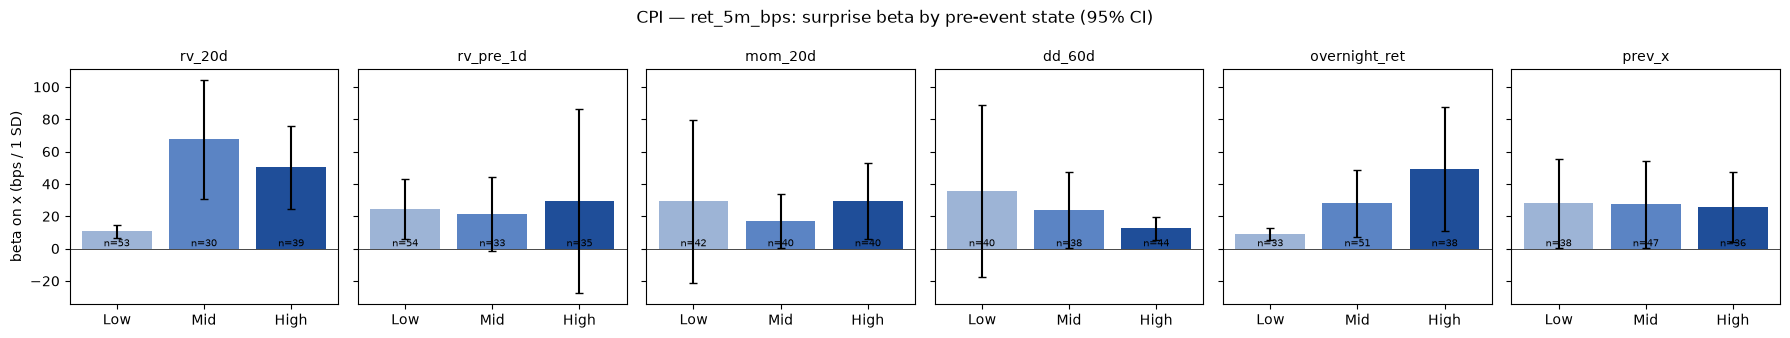

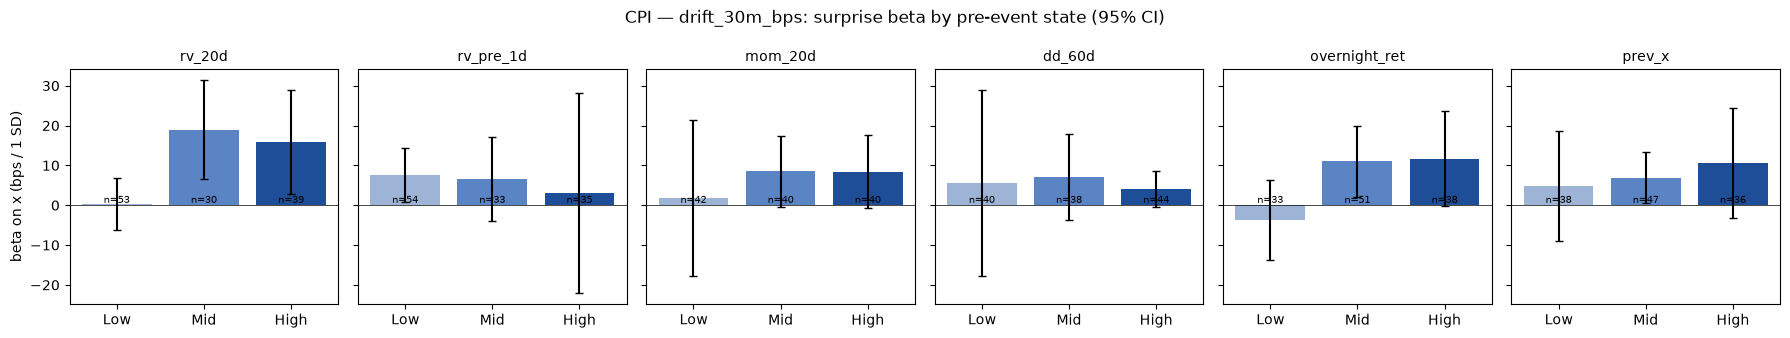

In [17]:
def plot_bucket_betas(bucket, family, target, states, fname):
    sub = bucket[(bucket.family == family) & (bucket.target == target) & bucket.state.isin(states)]
    fig, axes = plt.subplots(1, len(states), figsize=(3.0 * len(states), 3.4), sharey=True)
    for ax, s in zip(np.atleast_1d(axes), states):
        d = sub[sub.state == s].set_index("bucket").reindex(["Low", "Mid", "High"])
        ax.bar(d.index, d["beta"], yerr=1.96 * d["se"], capsize=3, color=["#9db4d6", "#5b84c4", "#1f4e99"])
        ax.axhline(0, c="k", lw=0.5)
        ax.set_title(s, fontsize=10)
        for k, (b, n) in enumerate(zip(d["beta"], d["n"])):
            if np.isfinite(b):
                ax.text(k, 0, f"n={int(n)}", ha="center", va="bottom", fontsize=7)
    np.atleast_1d(axes)[0].set_ylabel("beta on x (bps / 1 SD)")
    fig.suptitle(f"{family} — {target}: surprise beta by pre-event state (95% CI)")
    plt.tight_layout(); plt.savefig(FIGURES_DIR / fname, dpi=150); plt.show()

for tgt in PRIMARY_TARGETS:
    plot_bucket_betas(bucket, "CPI", tgt, PRIMARY_STATES, f"nb03_cpi_bucket_betas_{tgt}.png")

**How to read it.** Wide error bars are expected, since each CPI bucket holds about 40 events. Look for a **monotone** Low → Mid → High pattern that repeats across both targets. A single tall bar is not evidence on its own.

## 9. Interaction Regressions

Using the full sample in one regression is more efficient than splitting it into buckets:

$$r_i = a + b\,x_i + c\,s_i + d\,(x_i \times s_i) + \varepsilon_i, \qquad s_i = \text{pct}_i - 0.5$$

- $b$: surprise beta at the **median** state
- $c$: does the state predict the return on its own (direction)?
- $d$: **the key coefficient**, the change in surprise beta from the lowest to the highest state percentile

Since $x$ is signed so that $b>0$, a **positive $d$** means *a stronger reaction in the high state*.
The pooled (`ALL`) model has family-specific intercepts and slopes and a common $c$ and $d$.

In [18]:
inter = sc.interaction_tests(ev, ALL_STATES, FAMILIES, ALL_TARGETS,
                             n_perm=N_PERM, perm_targets=PRIMARY_TARGETS)
inter["primary_state"] = inter["state"].isin(PRIMARY_STATES)

# FDR is applied to the PRIMARY family of tests only (primary states x families x primary targets)
prim_mask = inter["primary_state"] & inter["target"].isin(PRIMARY_TARGETS)
inter["q_bh_primary"] = np.nan
inter.loc[prim_mask, "q_bh_primary"] = sc.bh_fdr(inter.loc[prim_mask, "p_interact"])
inter.to_csv(RESULTS_DIR / "nb03_interaction_results.csv", index=False)

print("Number of primary tests (FDR family):", prim_mask.sum())
display(
    inter[prim_mask]
    .sort_values("p_interact")
    [["state", "family", "target", "n", "b_x", "d_interact", "t_interact", "p_interact", "p_perm", "q_bh_primary", "r2"]]
    .round(4)
)

Number of primary tests (FDR family): 48


,state,family,target,n,b_x,d_interact,t_interact,p_interact,p_perm,q_bh_primary,r2
1,rv_20d,CPI,ret_5m_bps,122,34.8808,61.0672,3.8145,0.0002,0.0005,0.0105,0.4227
16,rv_20d,NFP,drift_30m_bps,121,2.5788,-12.1677,-2.9875,0.0034,0.0165,0.0823,0.0766
178,overnight_ret,ALL,drift_30m_bps,362,NaN,7.3537,2.6510,0.0084,0.0215,0.1342,0.0568
145,overnight_ret,CPI,ret_5m_bps,122,30.2345,72.1409,2.4850,0.0144,0.0335,0.1723,0.4273
106,mom_20d,ALL,drift_30m_bps,362,NaN,5.7438,2.2450,0.0254,0.0535,0.2437,0.0550
151,overnight_ret,CPI,drift_30m_bps,122,7.3937,27.7444,2.1248,0.0357,0.0475,0.2855,0.1362
7,rv_20d,CPI,drift_30m_bps,122,9.0148,21.4576,1.9897,0.0489,0.0640,0.3355,0.1688
142,dd_60d,ALL,drift_30m_bps,362,NaN,4.3179,1.7893,0.0744,0.1294,0.4007,0.0589
172,overnight_ret,ALL,ret_5m_bps,362,NaN,11.3956,1.7682,0.0779,0.0245,0.4007,0.2223
46,rv_pre_1d,NFP,ret_5m_bps,121,3.3636,-15.1577,-1.7458,0.0835,0.0490,0.4007,0.0399


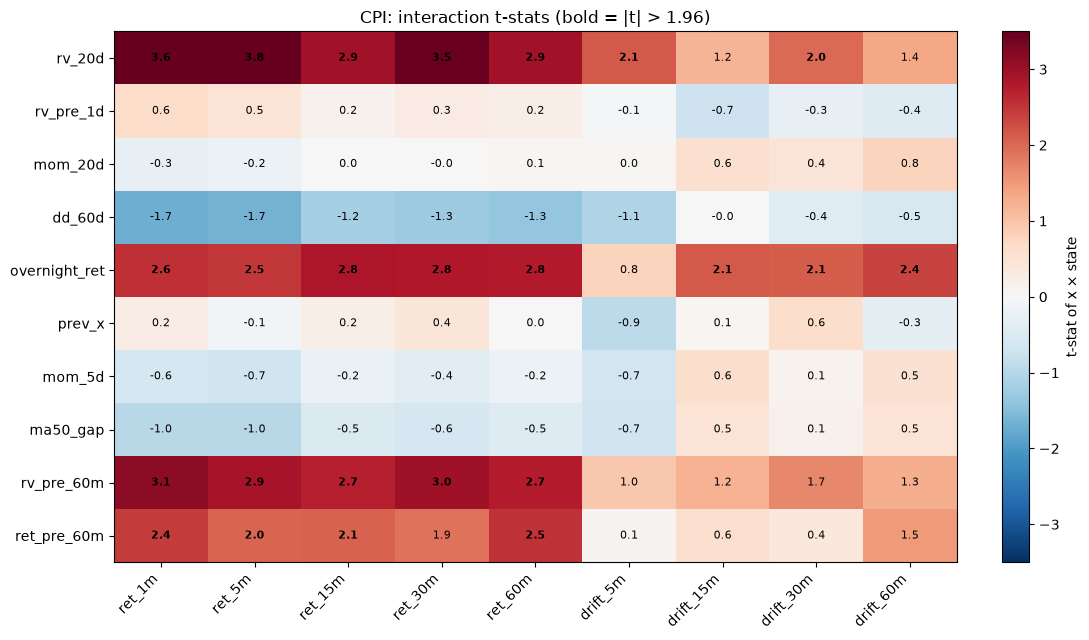

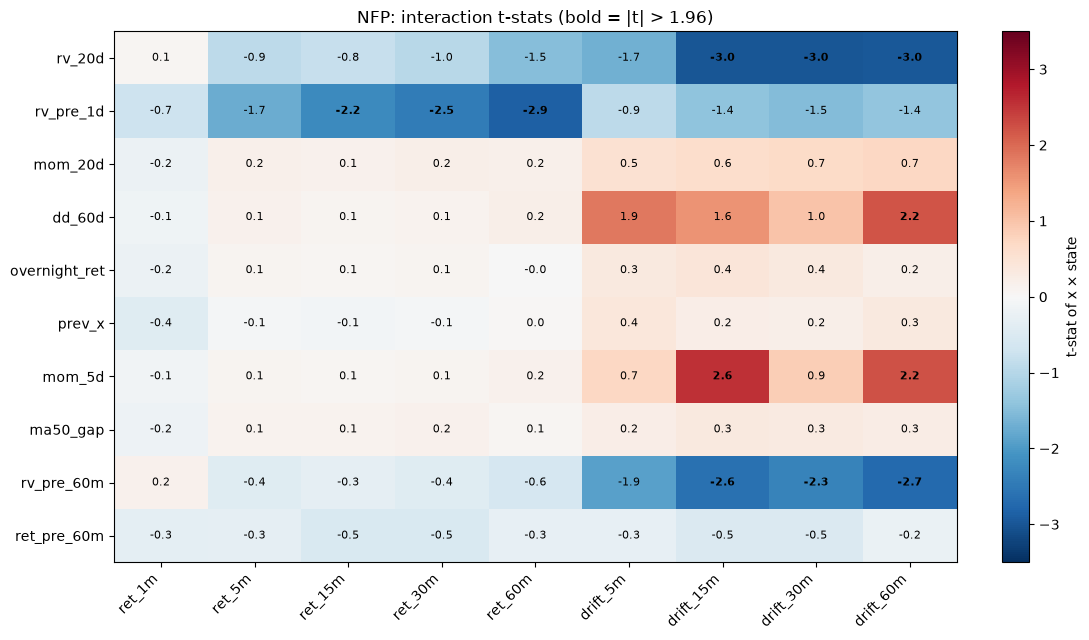

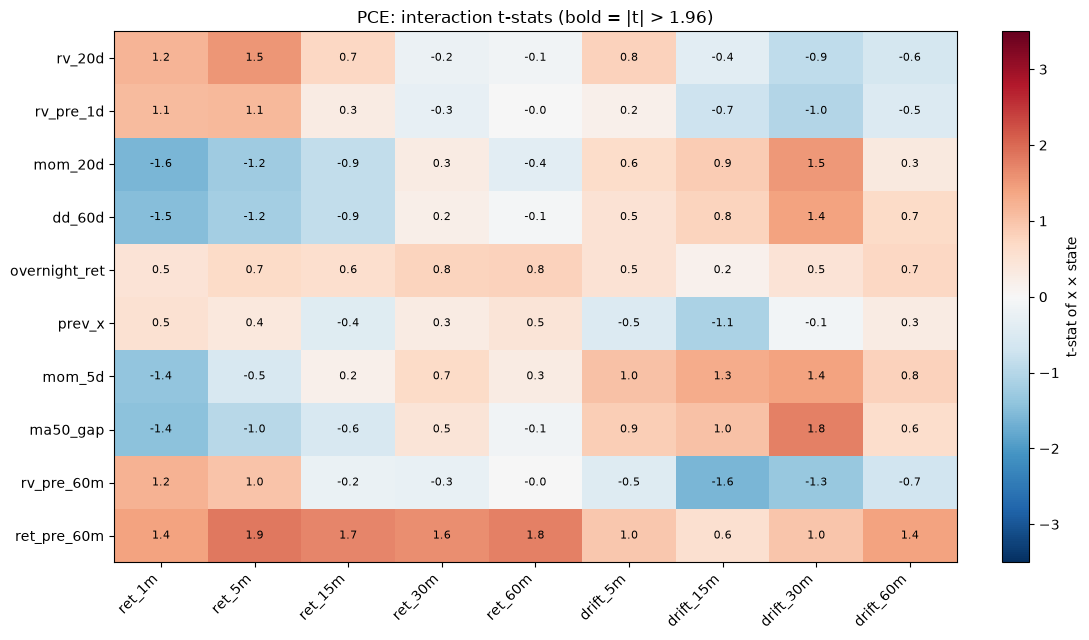

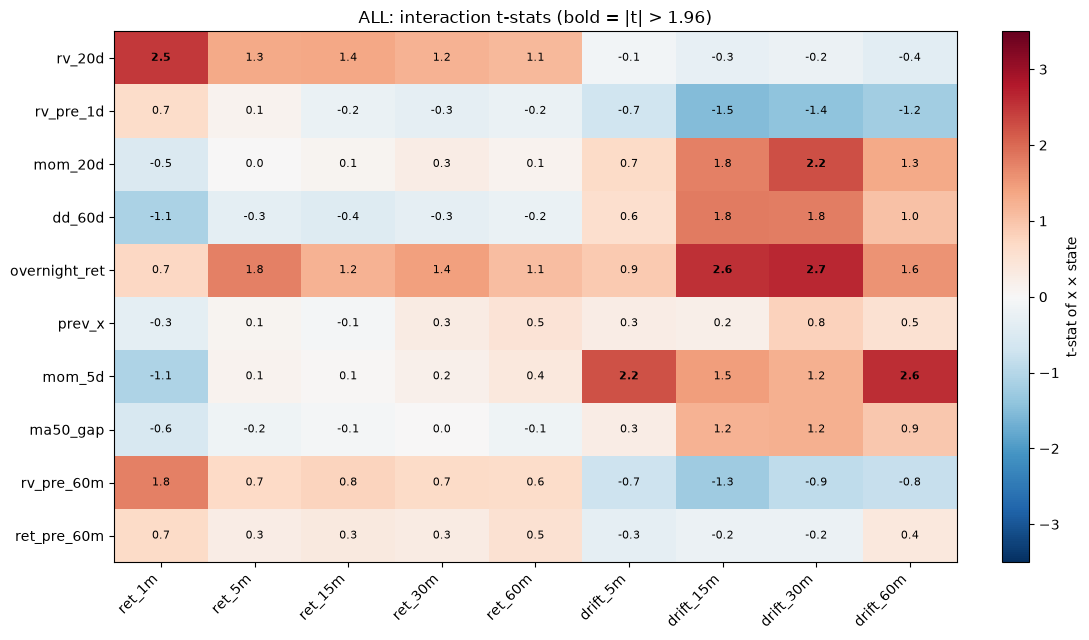

In [19]:
def tstat_heatmap(inter, family, states, targets, fname):
    m = (inter[(inter.family == family) & inter.state.isin(states)]
         .pivot_table(index="state", columns="target", values="t_interact")
         .reindex(index=states, columns=targets))
    fig, ax = plt.subplots(figsize=(1.0 * len(targets) + 2, 0.5 * len(states) + 1.5))
    im = ax.imshow(m.values, cmap="RdBu_r", vmin=-3.5, vmax=3.5, aspect="auto")
    ax.set_xticks(range(len(targets))); ax.set_xticklabels([t.replace("_bps", "") for t in targets], rotation=45, ha="right")
    ax.set_yticks(range(len(states))); ax.set_yticklabels(states)
    for i in range(m.shape[0]):
        for j in range(m.shape[1]):
            v = m.values[i, j]
            if np.isfinite(v):
                ax.text(j, i, f"{v:.1f}", ha="center", va="center", fontsize=8,
                        fontweight="bold" if abs(v) > 1.96 else "normal")
    plt.colorbar(im, ax=ax, fraction=0.03, label="t-stat of x × state")
    ax.set_title(f"{family}: interaction t-stats (bold = |t| > 1.96)")
    plt.tight_layout(); plt.savefig(FIGURES_DIR / fname, dpi=150); plt.show()

for fam in FAMILIES:
    tstat_heatmap(inter, fam, ALL_STATES, ALL_TARGETS, f"nb03_interaction_tstats_{fam}.png")

**How to read it.** A credible state effect looks like a **row of same-coloured cells** across horizons. A single bold cell among about 90 is what chance alone produces: at 5% significance, roughly 4–5 false positives are expected.

## 10. Permutation Tests and Multiple-Testing Control

- **Permutation p-value.** The state percentile is shuffled across events *within each family* 2,000 times. This breaks any link between the state and the surprise while keeping each family's returns intact. It makes no normality assumption.
- **BH-FDR q-value.** This controls the expected share of false discoveries across the primary tests.

,count
primary tests,48.0000
expected false positives at 5% (if no true effect),2.4000
naive p < 0.05,7.0000
permutation p < 0.05,8.0000
BH q < 0.1,2.0000


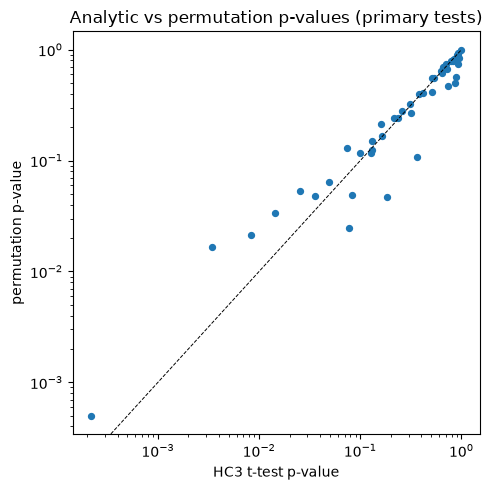

In [20]:
pt = inter[prim_mask].copy()
pt["sig_naive_5pct"] = pt["p_interact"] < 0.05
pt["sig_perm_5pct"] = pt["p_perm"] < 0.05
pt["sig_fdr"] = pt["q_bh_primary"] < FDR_Q

summary_mt = pd.Series({
    "primary tests": len(pt),
    "expected false positives at 5% (if no true effect)": round(0.05 * len(pt), 1),
    "naive p < 0.05": int(pt["sig_naive_5pct"].sum()),
    "permutation p < 0.05": int(pt["sig_perm_5pct"].sum()),
    f"BH q < {FDR_Q}": int(pt["sig_fdr"].sum()),
})
display(summary_mt.to_frame("count"))

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(pt["p_interact"], pt["p_perm"], s=18)
ax.plot([0, 1], [0, 1], "k--", lw=0.7)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("HC3 t-test p-value"); ax.set_ylabel("permutation p-value")
ax.set_title("Analytic vs permutation p-values (primary tests)")
plt.tight_layout(); plt.savefig(FIGURES_DIR / "nb03_pvalue_comparison.png", dpi=150); plt.show()

If the number of naive "significant" results is close to the expected false-positive count, the evidence for state dependence is weak **as a whole**, even if individual p-values look good.

## 11. Subperiod Stability

The sample spans two very different inflation regimes: low and stable in 2016–2020, then the 2021+ inflation shock and hiking cycle. A usable state effect should keep its sign in both.

In [21]:
stab = sc.subperiod_stability(ev, ALL_STATES, FAMILIES, ALL_TARGETS, split_date=SPLIT_DATE)
stab.to_csv(RESULTS_DIR / "nb03_subperiod_stability.csv", index=False)

display(
    stab[stab.state.isin(PRIMARY_STATES) & stab.target.isin(PRIMARY_TARGETS)]
    .sort_values(["family", "state", "target"])
    .round(3)
)

share = (stab[stab.state.isin(PRIMARY_STATES)]
         .groupby(["family", "state"])["same_sign"].mean().unstack("family").round(2))
print("Share of horizons with the same interaction sign in both subperiods:")
display(share)

,state,family,target,n_early,d_interact_early,t_interact_early,n_late,d_interact_late,t_interact_late,same_sign
142,dd_60d,ALL,drift_30m_bps,174,4.7660,1.5510,188,2.6610,0.2830,True
136,dd_60d,ALL,ret_5m_bps,174,0.7440,0.1340,188,-23.0480,-1.0680,False
106,mom_20d,ALL,drift_30m_bps,174,4.7410,1.1170,188,11.2120,0.9310,True
100,mom_20d,ALL,ret_5m_bps,174,0.3610,0.0230,188,1.6880,0.0490,True
178,overnight_ret,ALL,drift_30m_bps,174,4.0100,0.4670,188,27.1730,2.3780,True
172,overnight_ret,ALL,ret_5m_bps,174,2.2950,0.2000,188,64.2020,2.6070,True
214,prev_x,ALL,drift_30m_bps,171,2.1890,1.2500,187,-3.6000,-0.2980,False
208,prev_x,ALL,ret_5m_bps,171,0.2680,0.0880,187,4.4690,0.1960,True
34,rv_20d,ALL,drift_30m_bps,174,-7.9800,-1.3480,188,11.6070,0.9970,False
28,rv_20d,ALL,ret_5m_bps,174,-1.5430,-0.1750,188,56.5860,2.8410,False


Share of horizons with the same interaction sign in both subperiods:


family,ALL,CPI,NFP,PCE
state,,,,
dd_60d,0.3300,0.7800,0.5600,0.5600
mom_20d,0.8900,0.1100,0.2200,0.4400
overnight_ret,0.8900,0.7800,0.6700,0.6700
prev_x,0.3300,0.7800,0.2200,0.2200
rv_20d,0.1100,0.8900,1.0000,0.7800
rv_pre_1d,0.8900,0.2200,0.5600,0.4400


## 12. Does the State Predict the *Size* of the Move?

Even if the state does not change the *direction* coefficient, it may predict **how big** the move is, which matters for position sizing and risk limits in Notebook 04:

$$|r_i| = a + g\,|x_i| + h\,s_i + \varepsilon_i$$

In [22]:
mag = sc.magnitude_tests(ev, ALL_STATES, FAMILIES, ALL_TARGETS)
mag.to_csv(RESULTS_DIR / "nb03_magnitude_results.csv", index=False)

display(
    mag[mag.state.isin(PRIMARY_STATES) & mag.target.isin(["ret_5m_bps", "ret_30m_bps", "drift_30m_bps"])]
    .sort_values("p_state")
    .round(4)
    .head(20)
)

,state,family,target,n,r2,g_abs_x,h_state,t_state,p_state,q_bh
142,dd_60d,ALL,drift_30m_bps,362,0.1161,0.6437,-19.8971,-5.4441,0.0000,0.0000
34,rv_20d,ALL,drift_30m_bps,362,0.1052,0.5625,18.1680,5.2024,0.0000,0.0000
70,rv_pre_1d,ALL,drift_30m_bps,362,0.0791,0.5596,15.7375,4.3338,0.0000,0.0005
28,rv_20d,ALL,ret_5m_bps,362,0.0457,0.6067,21.7662,3.9397,0.0001,0.0015
30,rv_20d,ALL,ret_30m_bps,362,0.0491,0.9743,25.7204,3.9307,0.0001,0.0015
136,dd_60d,ALL,ret_5m_bps,362,0.0605,0.7044,-26.3231,-3.8897,0.0001,0.0016
106,mom_20d,ALL,drift_30m_bps,362,0.0627,0.7375,-13.8612,-3.8857,0.0001,0.0016
138,dd_60d,ALL,ret_30m_bps,362,0.0541,1.0892,-28.2325,-3.7091,0.0002,0.0025
124,dd_60d,NFP,drift_30m_bps,121,0.1375,0.5801,-19.3236,-3.5530,0.0005,0.0038
147,overnight_ret,CPI,ret_30m_bps,122,0.2007,17.4748,82.5986,3.5370,0.0006,0.0039


**Expected pattern.** Volatility states (`rv_20d`, `rv_pre_1d`) usually show a strong positive $h$: in high-vol regimes, moves are bigger regardless of the surprise. That is useful for **risk scaling** even if it does not improve the **directional** signal.

## 13. Pre-Registered Selection Rule and Hand-off to Notebook 04

A (state, family) pair is carried into Notebook 04 only if, on a primary target, it passes **all** of these:

1. BH-FDR q < 0.10 (primary test family)
2. permutation p < 0.05
3. the interaction has the same sign in 2016–2020 and in 2021–2026
4. the interaction sign agrees on at least 60% of all nine targets

If nothing passes, Notebook 04 uses the **surprise-only** model as the main strategy, and state is used only for risk scaling (Section 12), if at all.

In [23]:
inter_primary = inter[prim_mask].copy()
inter_primary["q_bh"] = inter_primary["q_bh_primary"]   # use the primary-family FDR
all_for_agreement = inter[inter.state.isin(PRIMARY_STATES)].copy()

# horizon agreement uses ALL targets; significance uses the primary targets only
sel = sc.select_states(
    pd.concat([inter_primary, all_for_agreement[~all_for_agreement.index.isin(inter_primary.index)]]),
    stab, PRIMARY_TARGETS, q_max=FDR_Q,
)
sel.to_csv(RESULTS_DIR / "nb03_state_selection.csv", index=False)

display(sel[["state", "family", "target", "n", "d_interact", "t_interact", "p_perm", "q_bh",
             "same_sign", "horizon_sign_agreement",
             "pass_fdr", "pass_perm", "pass_stability", "pass_horizons", "selected"]].round(3))

selected_pairs = sel.loc[sel["selected"], ["state", "family"]].drop_duplicates()
print("\nSELECTED (state, family) pairs for Notebook 04:")
print(selected_pairs.to_string(index=False) if len(selected_pairs) else "  none. Use surprise-only as the main model.")

,state,family,target,n,d_interact,t_interact,p_perm,q_bh,same_sign,horizon_sign_agreement,pass_fdr,pass_perm,pass_stability,pass_horizons,selected
0,rv_20d,CPI,ret_5m_bps,122,61.0670,3.8140,0.0000,0.0100,True,1.0000,True,True,True,True,True
3,rv_20d,NFP,drift_30m_bps,121,-12.1680,-2.9870,0.0160,0.0820,True,0.8890,True,True,True,True,True
39,overnight_ret,ALL,drift_30m_bps,362,7.3540,2.6510,0.0210,0.1340,True,1.0000,False,True,True,True,False
32,overnight_ret,CPI,ret_5m_bps,122,72.1410,2.4850,0.0330,0.1720,True,1.0000,False,True,True,True,False
23,mom_20d,ALL,drift_30m_bps,362,5.7440,2.2450,0.0530,0.2440,True,0.8890,False,False,True,True,False
33,overnight_ret,CPI,drift_30m_bps,122,27.7440,2.1250,0.0470,0.2860,False,1.0000,False,True,False,True,False
1,rv_20d,CPI,drift_30m_bps,122,21.4580,1.9900,0.0640,0.3360,True,1.0000,False,False,True,True,False
10,rv_pre_1d,NFP,ret_5m_bps,121,-15.1580,-1.7460,0.0490,0.4010,True,1.0000,False,True,True,True,False
31,dd_60d,ALL,drift_30m_bps,362,4.3180,1.7890,0.1290,0.4010,True,0.5560,False,False,True,False,False
38,overnight_ret,ALL,ret_5m_bps,362,11.3960,1.7680,0.0240,0.4010,True,1.0000,False,True,True,True,False



SELECTED (state, family) pairs for Notebook 04:
 state family
rv_20d    CPI
rv_20d    NFP


### 13.1 Save the event state dataset for Notebook 04

In [24]:
keep = (
    ["timestamp_utc", "event_type", "date_et", "clock_et", "asof_utc", "feat_date_et", "x", "abs_x", "pre_close"]
    + [c for c in events.columns if c.startswith("ret_")]
    + DRIFT_TARGETS
    + [c for s in ALL_STATES for c in (s, f"{s}_pct", f"{s}_bucket")]
    + ["prev_x"]
    + ["avg_hourly_earnings", "core_cpi", "core_pce", "headline_cpi", "headline_pce", "nonfarm_payrolls", "unemployment_rate"]
)
keep = list(dict.fromkeys(c for c in keep if c in ev.columns))
state_out = ev[keep].copy()
for s in ALL_STATES:
    state_out[f"{s}_bucket"] = state_out[f"{s}_bucket"].astype(str)

STATE_FILE = PROCESSED_DIR / "event_state_features_2016_2026.parquet"
state_out.to_parquet(STATE_FILE, index=False)
state_out.to_csv(PROCESSED_DIR / "event_state_features_2016_2026.csv", index=False)

check = pd.read_parquet(STATE_FILE)
assert len(check) == len(events)
assert check["timestamp_utc"].is_unique
print("Saved:", STATE_FILE, check.shape)

Saved: /Users/reza/Desktop/mfe-term_3/BlackRock-Project-State-Dependent-Intraday-Response-of-S-P-500-Futures-to-Macroeconomic-Surprises/data/processed/event_state_features_2016_2026.parquet (363, 55)


### 13.2 Final validation and results summary

In [25]:
print("=" * 78)
print("NOTEBOOK 03 SUMMARY")
print("=" * 78)
print(f"Events: {len(ev)}  ({ev['timestamp_utc'].min().date()} to {ev['timestamp_utc'].max().date()})")
print(f"Primary states: {len(PRIMARY_STATES)}   Primary targets: {PRIMARY_TARGETS}")
print(f"Primary interaction tests: {len(pt)}  |  naive p<0.05: {int(pt['sig_naive_5pct'].sum())}"
      f"  |  perm p<0.05: {int(pt['sig_perm_5pct'].sum())}  |  BH q<{FDR_Q}: {int(pt['sig_fdr'].sum())}")

best = pt.sort_values("p_interact").head(5)[["state", "family", "target", "d_interact", "t_interact", "p_perm", "q_bh_primary"]]
print("\nStrongest primary interactions:")
print(best.round(3).to_string(index=False))

mag_best = (mag[mag.state.isin(PRIMARY_STATES) & (mag.target == "ret_5m_bps")]
            .sort_values("p_state").head(5)[["state", "family", "h_state", "t_state", "q_bh"]])
print("\nStrongest magnitude (|return|) effects, ret_5m:")
print(mag_best.round(3).to_string(index=False))

print("\nSelected for NB04:", selected_pairs.values.tolist() if len(selected_pairs) else "none (surprise-only baseline)")
print("\nOutputs:")
for f in ["nb03_bucket_betas.csv", "nb03_interaction_results.csv", "nb03_subperiod_stability.csv",
          "nb03_magnitude_results.csv", "nb03_state_selection.csv"]:
    print("  results/" + f)
print("  data/processed/event_state_features_2016_2026.parquet")

NOTEBOOK 03 SUMMARY
Events: 363  (2016-01-08 to 2026-06-25)
Primary states: 6   Primary targets: ['ret_5m_bps', 'drift_30m_bps']
Primary interaction tests: 48  |  naive p<0.05: 7  |  perm p<0.05: 8  |  BH q<0.1: 2

Strongest primary interactions:
        state family        target  d_interact  t_interact  p_perm  q_bh_primary
       rv_20d    CPI    ret_5m_bps     61.0670      3.8140  0.0000        0.0100
       rv_20d    NFP drift_30m_bps    -12.1680     -2.9870  0.0160        0.0820
overnight_ret    ALL drift_30m_bps      7.3540      2.6510  0.0210        0.1340
overnight_ret    CPI    ret_5m_bps     72.1410      2.4850  0.0330        0.1720
      mom_20d    ALL drift_30m_bps      5.7440      2.2450  0.0530        0.2440

Strongest magnitude (|return|) effects, ret_5m:
    state family  h_state  t_state   q_bh
   rv_20d    ALL  21.7660   3.9400 0.0020
   dd_60d    ALL -26.3230  -3.8900 0.0020
   rv_20d    NFP  22.4300   3.4050 0.0050
rv_pre_1d    ALL  15.6150   3.1550 0.0080
rv_pre_1

## 14. Interpretation and Conclusion

*Fill this in after running, using the summary above. Suggested structure:*

**1. Directional state dependence.** Which primary states, if any, changed the surprise beta for CPI? Give the sign and size of $d$ in bps, and whether the effect held up after FDR, permutation, and subperiod checks.

**2. Magnitude.** Did volatility states predict larger absolute moves? That is useful for sizing even when direction is unaffected.

**3. Instant response vs drift.** Does state matter more for the instant jump (`ret_5m`) or for the tradeable post-release drift (`drift_30m`)? Only the latter can be monetised.

**4. Implication for Notebook 04.**
- *Surprise only:* trade the sign of $x$ (CPI first), entering at the $T$ bar close.
- *Surprise + state:* use the selected state(s) to scale or filter trades.
- If no state passed, say so plainly. A null result from a pre-registered, look-ahead-free test is a credible finding, and far better than a data-mined one.

**Caveats.** There are about 120 events per family, so buckets hold about 40 events. States are correlated (volatility and drawdown). And the 2021+ inflation regime dominates CPI's economic significance.

# 14. Purpose, Research Questions, and Answers

## Purpose of Notebook 03

Notebook 02 showed that ES responds to macroeconomic surprises, mainly CPI: a 1-SD hotter headline CPI print lowers ES by roughly 18–24 bps. That estimate is an **average reaction across all releases**.

Notebook 03 asks whether this reaction **depends on the market's state before the release**. For example, does the same CPI surprise have a larger effect when the market is already volatile?

- If **yes**, the pre-release state can decide *when* to trade and *how large* the position should be.
- If **no**, the surprise-only strategy is the correct benchmark.

Either way, the result determines what Notebook 04 builds.

---

## Research Questions and Answers

### Section 2: Is the surprise signal defined correctly?
**Question:** If each release gets one signed surprise $x$ (with $x>0$ meaning good news for equities), is $x$ related to ES returns in the expected direction?

**Answer:** Yes. The correlation between $x$ and the 5-minute return is **0.51 for CPI**, **0.31 for PCE**, and **0.13 for NFP**. This is consistent with Notebook 02: CPI is the strongest signal and NFP the weakest.

### Section 3: Can we trust multi-day features from a continuous futures series?
**Question:** `ES.c.0` jumps at every quarterly contract roll. Would these jumps contaminate momentum and drawdown?

**Answer:** They would have. **64 rolls** were detected, with price jumps of up to several hundred bps. The roll-adjusted series removes these jumps while leaving within-contract returns exactly unchanged (maximum difference = 0).

### Section 4: What did the market's daily state look like from 2010 to 2026?
**Question:** Do the daily state variables (volatility, momentum, drawdown) behave sensibly?

**Answer:** Yes. 20-day realised volatility has a median of about **13%** and spikes to about **100%** in March 2020. The 60-day drawdown reaches **−35%**. Known market regimes are clearly visible.

### Section 5: Are the state variables free of look-ahead bias?
**Question:** Does any state variable use information that becomes available only after the release?

**Answer:** No. **All look-ahead checks passed.** Every feature uses data up to the $T-1$ minute bar, and the price at that bar exactly matches Notebook 02's `pre_close`. Daily features come from the previous trading day's close.

### Section 6: How much of the reaction is actually tradeable?
**Question:** Notebook 02 returns include the instantaneous first-minute jump, which no strategy can capture. How much reaction remains after the first minute?

**Answer:** For CPI, the 30-minute post-release drift averages about **20 bps in absolute size**. Its sensitivity to the surprise is about **9 bps per 1-SD surprise**, compared with about **35 bps** for the full 5-minute response. Most of the reaction is immediate, but a tradeable part remains.

### Section 7: Are the state variables distinct from each other?
**Question:** Are we measuring six different states, or the same state six times?

**Answer:** They partly overlap. Volatility and drawdown are strongly correlated (Spearman correlations of **−0.6 to −0.8**), so together they describe one **stress regime**. The overnight return and the previous surprise are largely independent of the other states.

### Section 8: Does the surprise beta differ across Low, Mid, and High states?
**Question:** If CPI releases are split into terciles by pre-event state, does the response to the same surprise change?

**Answer:**
- **20-day volatility:** yes. The CPI beta is about **11 bps** in the low-volatility tercile, compared with **50–68 bps** in the mid and high terciles.
- **Overnight return:** the CPI beta rises monotonically, **9 → 28 → 50 bps**.
- **Other states:** no clear pattern.

### Section 9: Is the state effect statistically significant?
**Question:** In the regression $r = a + b\,x + c\,s + d\,(x \times s)$, is the interaction coefficient $d$ significant?

**Answer:**
- **CPI × 20-day volatility** is the strongest effect (**t = 3.8**). Moving from the calmest to the most volatile conditions raises the CPI beta by about **61 bps**.
- **NFP × volatility** is also significant, but negative (**t = −3.0**).
- Momentum, drawdown, and the previous surprise show **no significant effect**.

### Section 10: Could these results be luck from running many tests?
**Question:** With 48 primary tests, some results will look significant by chance. How many survive proper correction?

**Answer:** About **2.4** false positives are expected by chance alone; **7** tests are significant before correction. After Benjamini–Hochberg FDR correction, **2 survive**: CPI × volatility and NFP × volatility. The evidence is **real but modest**.

### Section 11: Is the effect stable over time?
**Question:** Does the effect hold in both 2016–2020 (low inflation) and 2021–2026 (the inflation shock)?

**Answer:** Only partially.
- **CPI × volatility** has the same sign in both periods, but is **significant only after 2021**. Part of the effect may reflect the inflation regime rather than volatility itself.
- **NFP × volatility** is driven mainly by the **pre-2021** period, which makes it fragile.

### Section 12: Does the state predict the size of the move?
**Question:** Setting direction aside, are ES moves larger in certain states?

**Answer:** **Yes. This is the most robust finding of the notebook.** In high 20-day volatility the absolute move is about **20 bps larger** (t ≈ 4–5), and deeper drawdowns are also associated with larger moves. **198 of 360** magnitude tests survive FDR correction.

### Section 13: Which states are carried into Notebook 04?
**Question:** Which (state, family) pairs pass all four pre-registered criteria: FDR, permutation test, subperiod stability, and horizon consistency?

**Answer:** `rv_20d × CPI` and `rv_20d × NFP`. Given the subperiod evidence, **only CPI × volatility is credible for trading**.

---

## Overall Conclusion

The pre-release market state matters in two ways:

1. **Direction:** CPI surprises move ES much more when 20-day volatility is elevated. In calm markets the CPI effect is small. The evidence is strong, but concentrated in 2021–2026.
2. **Size:** volatility and drawdown reliably predict **how large** the move will be, independent of the surprise.

## Implications for Notebook 04

| Model | Specification |
|---|---|
| **Surprise only** (baseline) | Trade the sign of the CPI surprise, entering at the close of the first post-release minute and holding for 30 minutes |
| **Surprise + State** | Trade CPI mainly when `rv_20d` is not in its low tercile, and scale position size by volatility |
| **NFP** | Excluded from directional trading (weak baseline signal, unstable state effect) |

**Caveats:** there are only about 120 events per family (about 40 per tercile), volatility and drawdown are correlated, and the CPI effect is concentrated in the post-2021 inflation regime. The state rule must therefore be re-estimated **walk-forward** in Notebook 04.